In [43]:
import pandas as pd
import numpy as np

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
df = pd.read_excel("/content/drive/My Drive/Colab Notebooks/cases_rainfall_data/total_precipitation_daily_DISTRICT.xlsx")
df.head()
# df['total_precipitation'] = df['total_precipitation'] / 24.  # divide by 24h since it's hourly rainfall integrated over 1 day

,date,DISTRICT_S,total_precipitation
0,2021-10-01,Abo,0.010525
1,2021-10-01,Abong Mbang,0.007632
2,2021-10-01,Ako,0.024133
3,2021-10-01,Akonolinga,0.005898
4,2021-10-01,Akwaya,0.019412


In [46]:
df = df[df['total_precipitation'] < 100.]  # filter out districts with nonsensical values
df.describe()

,date,total_precipitation
count,150865,1.508650e+05
mean,2022-11-18 01:42:15.880422912,5.062465e-03
min,2021-10-01 00:00:00,3.000000e-08
25%,2022-05-01 00:00:00,9.955000e-05
50%,2022-11-15 00:00:00,1.792440e-03
75%,2023-06-12 00:00:00,7.511870e-03
max,2023-12-31 00:00:00,1.532586e-01
std,NaN,7.982451e-03


In [47]:
len(df[df['total_precipitation'] > 0.05])

663

In [48]:
incidence_df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/cases_rainfall_data/District_Incidence.csv")

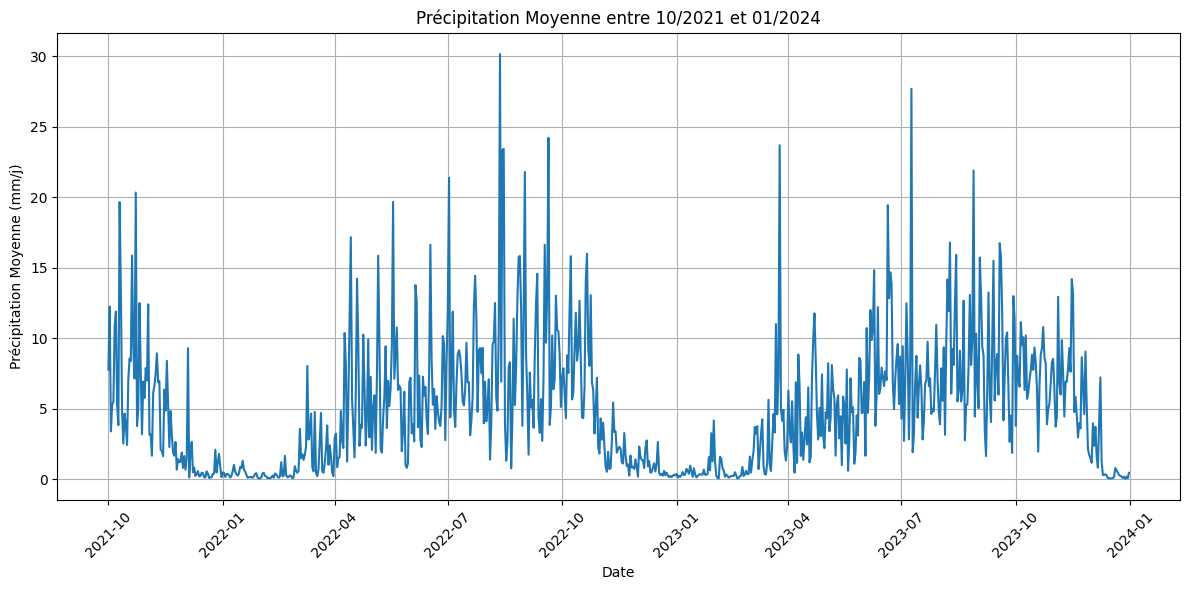

In [49]:
# prompt: plot precipitation data on a timeline

import matplotlib.pyplot as plt

# Convert the 'date' column to datetime objects if it's not already.
df['date'] = pd.to_datetime(df['date'])

# Group data by date and sum precipitation for each date
precipitation_by_date = (df.groupby('date')['total_precipitation'].mean())*1000
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.plot(precipitation_by_date.index, precipitation_by_date.values)
plt.xlabel('Date')
plt.ylabel('Précipitation Moyenne (mm/j)')
plt.title('Précipitation Moyenne entre 10/2021 et 01/2024')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [50]:
# prompt: give a list of the districts with the highest precipitation values and the date it occured on

# Find the maximum precipitation for each district
max_precipitation_by_district = df.groupby('DISTRICT_S')['total_precipitation'].max()

# Get the dates corresponding to the maximum precipitation for each district
max_precipitation_dates = {}
for district in max_precipitation_by_district.index:
    max_precipitation = max_precipitation_by_district[district]
    date = df[(df['DISTRICT_S'] == district) & (df['total_precipitation'] == max_precipitation)]['date'].values[0]
    max_precipitation_dates[district] = date


# Create a DataFrame from the results
result_df = pd.DataFrame({
    'DISTRICT_S': max_precipitation_dates.keys(),
    'Max Precipitation': max_precipitation_by_district.values,
    'Date of Max Precipitation': max_precipitation_dates.values()
})

# Sort the DataFrame by max precipitation in descending order to show the highest values first.
result_df = result_df.sort_values('Max Precipitation', ascending=False)

result_df

,DISTRICT_S,Max Precipitation,Date of Max Precipitation
85,Kumba North,0.153259,2022-08-12
37,Buea,0.133349,2021-10-23
81,Konye,0.132472,2022-08-12
122,Mogode,0.132463,2023-08-25
29,Benakuma,0.128520,2023-08-14
...,...,...,...
95,Mada,0.032445,2022-09-17
31,Bibemi,0.031763,2023-08-27
146,Ngong,0.031263,2022-09-01
148,Nguelemendouka,0.029687,2022-04-19


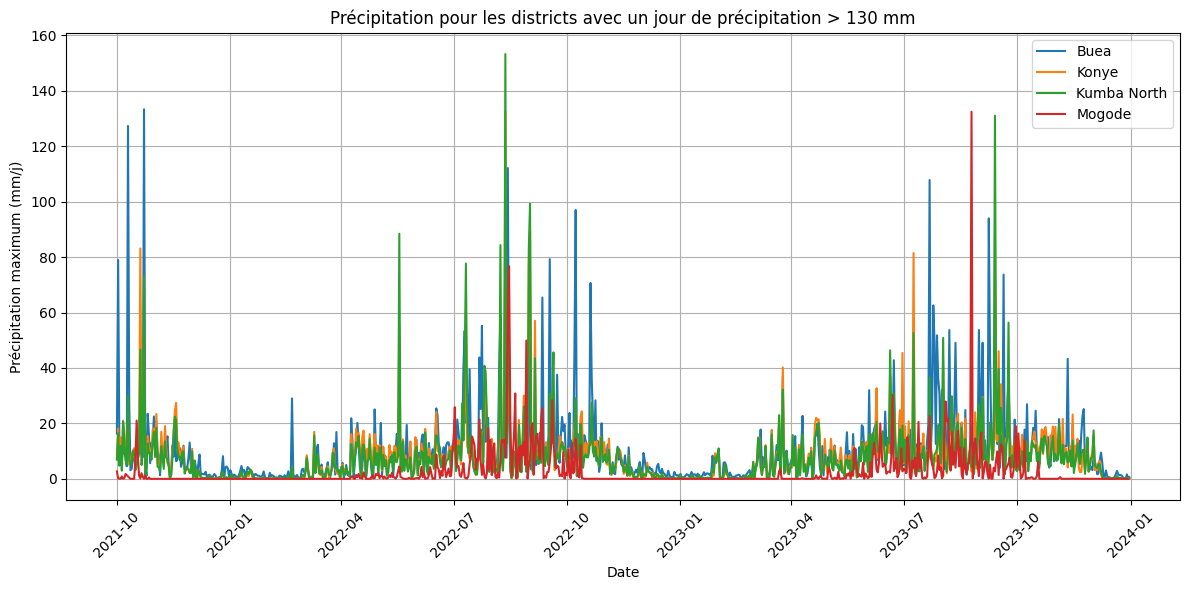

In [51]:
# prompt: plot precipitation data on a timeline of all districts with a day value of precipitation at one point about 0.13, including all datapoints for those districts in the timeline

import matplotlib.pyplot as plt

# Find districts with at least one day's precipitation exceeding 0.13
districts_above_threshold = df[df['total_precipitation'] > 0.13]['DISTRICT_S'].unique()

# Filter the DataFrame to include only data from the identified districts
filtered_df = df[df['DISTRICT_S'].isin(districts_above_threshold)]

# Group data by district and date, then plot
plt.figure(figsize=(12, 6))
for district in districts_above_threshold:
    district_data = filtered_df[filtered_df['DISTRICT_S'] == district]
    plt.plot(district_data['date'], (district_data['total_precipitation'])*1000, label=district)

plt.xlabel('Date')
plt.ylabel('Précipitation maximum (mm/j)')
plt.title('Précipitation pour les districts avec un jour de précipitation > 130 mm')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
incidence_df.head()

,start_date,end_date,NOM_REGION,DISTRICT_S,cases,deaths
0,29/10/2021,01/11/2021,Centre,Biyem-Assi,32,1
1,29/10/2021,01/11/2021,Sud-Ouest,Ekondo Titi,23,3
2,02/11/2021,11/11/2021,Centre,Biyem-Assi,40,0
3,02/11/2021,11/11/2021,Centre,Efoulan,3,0
4,02/11/2021,11/11/2021,Centre,Mfou,1,0


<ipython-input-53-7093eb71603b>:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])


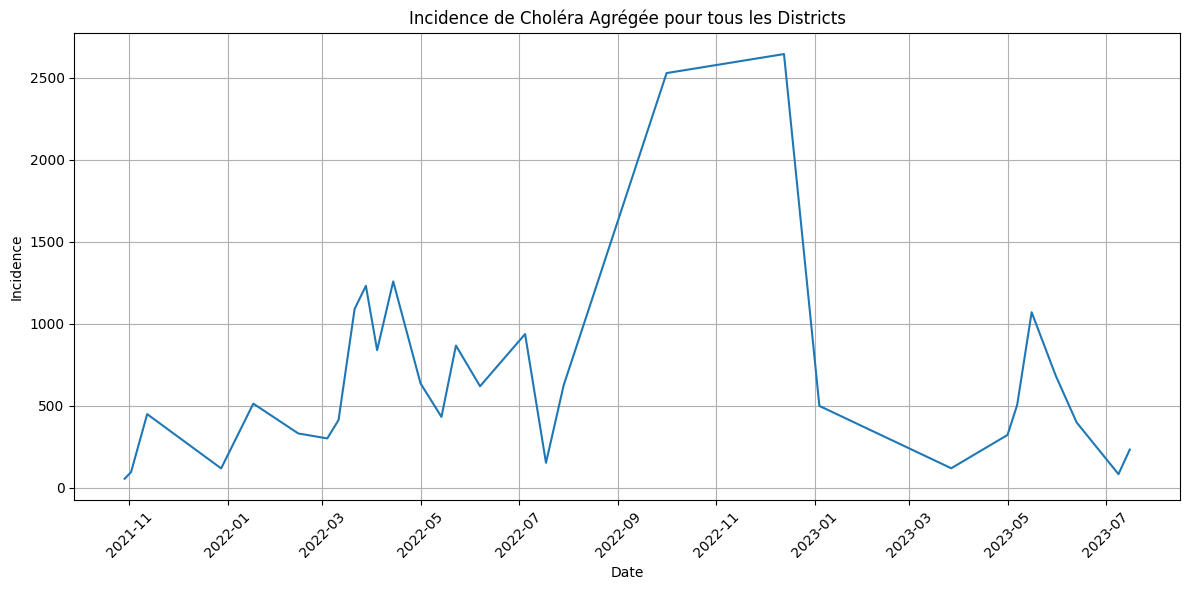

In [53]:
# prompt: create a plot of incidence data on a timeline of start_date

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and already loaded
# If not, load your data here:
# df = pd.read_excel(...)

# Assuming 'start_date' is your date column and 'incidence' is your incidence data column.
# Replace with your actual column names

# Convert the start_date column to datetime objects if it's not already.
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Group data by start_date and sum incidence for each date (or use another aggregation like mean)
incidence_by_date = incidence_df.groupby('start_date')['cases'].sum()

plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.plot(incidence_by_date.index, incidence_by_date.values)
plt.xlabel('Date')
plt.ylabel('Incidence')
plt.title('Incidence de Choléra Agrégée pour tous les Districts')
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

<ipython-input-54-d53c89de6c23>:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


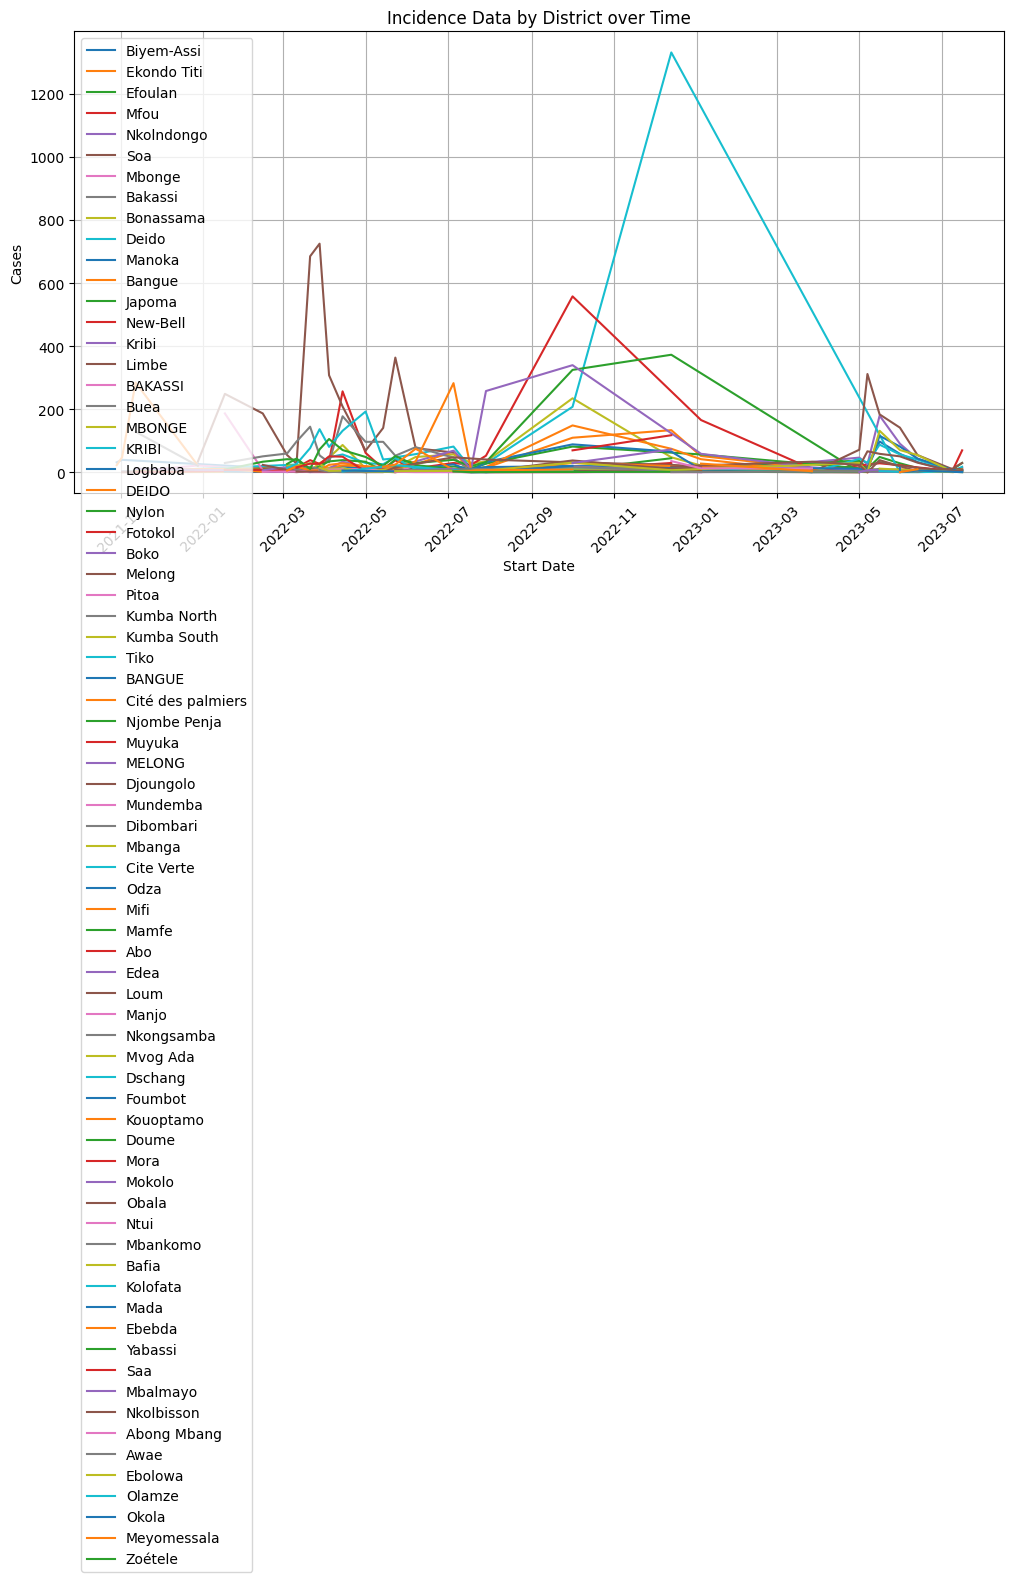

In [54]:
# prompt: create a plot of incidence data on a timeline of start_date by district cases on y axis, districts as not cumulated to sum per district

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your incidence data is in 'incidence_df'
# and 'start_date' and 'cases' are the relevant columns.

# Convert 'start_date' to datetime objects if needed
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Create the plot
plt.figure(figsize=(12, 6))

for district in incidence_df['DISTRICT_S'].unique():
    district_data = incidence_df[incidence_df['DISTRICT_S'] == district]
    plt.plot(district_data['start_date'], district_data['cases'], label=district)

plt.xlabel('Start Date')
plt.ylabel('Cases')
plt.title('Incidence Data by District over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()  # Show the legend for districts
plt.tight_layout()
plt.show()

In [55]:
# Calculate the average precipitation for each district
#average_precipitation_by_district = df.groupby('DISTRICT_S')['total_precipitation'].mean()

# Filter districts where the average precipitation is above x
districts_above_avg_precipitation = df[df['total_precipitation'] > 0.1]['DISTRICT_S'].unique()

# Filter the incidence DataFrame for cases above y
districts_above_zero_cases = incidence_df[incidence_df['cases'] > 150]['DISTRICT_S'].unique()

# Find the intersection of the two sets of districts
districts_meeting_both_criteria = set(districts_above_avg_precipitation) & set(districts_above_zero_cases)

print("Districts with meeting criteria:")
districts_meeting_both_criteria

Districts with meeting criteria:


{'Boko',
 'Bonassama',
 'Buea',
 'Cité des palmiers',
 'Deido',
 'New-Bell',
 'Nylon'}

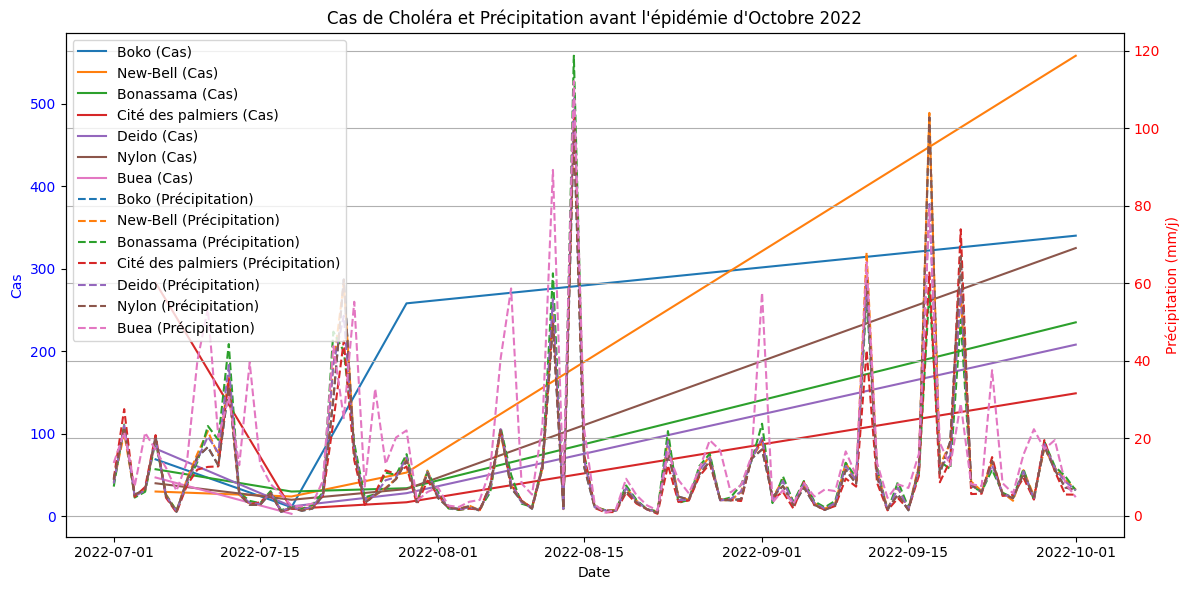

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrames are named 'df' and 'incidence_df' and already loaded
# If not, load your data here:
# df = pd.read_excel(...)
# incidence_df = pd.read_csv(...)

# Convert date columns to datetime objects if they aren't already
df['date'] = pd.to_datetime(df['date'])
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Filter for the specified timeline
start_date = pd.to_datetime('2022-07-01')
end_date = pd.to_datetime('2022-10-01')

filtered_df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]
filtered_incidence_df = incidence_df[(incidence_df['start_date'] >= start_date) & (incidence_df['start_date'] <= end_date)]


# Filter districts meeting both criteria (adjust thresholds as needed)
districts_above_avg_precipitation = df[df['total_precipitation'] > 0.1]['DISTRICT_S'].unique()
districts_above_zero_cases = incidence_df[incidence_df['cases'] > 150]['DISTRICT_S'].unique()
districts_meeting_both_criteria = set(districts_above_avg_precipitation) & set(districts_above_zero_cases)

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot cases on the left axis
for district in districts_meeting_both_criteria:
    district_incidence = filtered_incidence_df[filtered_incidence_df['DISTRICT_S'] == district]
    ax1.plot(district_incidence['start_date'], district_incidence['cases'], label=f"{district} (Cas)")

ax1.set_xlabel('Date')
ax1.set_ylabel('Cas', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second axis for precipitation
ax2 = ax1.twinx()

# Plot precipitation on the right axis with dotted lines
for district in districts_meeting_both_criteria:
    district_data = filtered_df[filtered_df['DISTRICT_S'] == district]
    ax2.plot(district_data['date'], district_data['total_precipitation']*1000, linestyle='--', label=f"{district} (Précipitation)")


ax2.set_ylabel('Précipitation (mm/j)', color='red')
ax2.tick_params(axis='y', labelcolor='red')


# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')


plt.title(f"Cas de Choléra et Précipitation avant l'épidémie d'Octobre 2022")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
df['date'] = pd.to_datetime(df['date'])
df['total_precipitation'] = df['total_precipitation'].astype(float)
for n in range(2, 22):
    df_n = df.groupby(['DISTRICT_S', 'date']).mean().reset_index(drop=True)
    df_n = df_n.rolling(n).mean()
    print(n, len(df_n[df_n['total_precipitation'] > 0.05]))

2 303
3 86
4 39
5 11
6 0
7 0
8 0
9 0
10 0
11 0
12 0
13 0
14 0
15 0
16 0
17 0
18 0
19 0
20 0
21 0


Average Correlation Results per District:
             district  average_correlation
0                 Abo            -0.582278
1              Bangue             0.064036
2          Biyem-Assi             0.155809
3                Boko             0.273448
4           Bonassama             0.317586
5                Buea            -0.293775
6   Cité des palmiers             0.133877
7          Cite Verte             0.237090
8               Deido            -0.059005
9           Dibombari             0.300165
10          Djoungolo             0.049109
11              Doume             0.018496
12            Dschang             0.356027
13             Ebebda             0.250000
14            Ebolowa             0.500000
15            Efoulan             0.152013
16            Fotokol            -0.534568
17            Foumbot             0.450099
18              Pitoa            -0.186751
19             Japoma             0.132404
20          Kouoptamo             0.262184
21        Ku

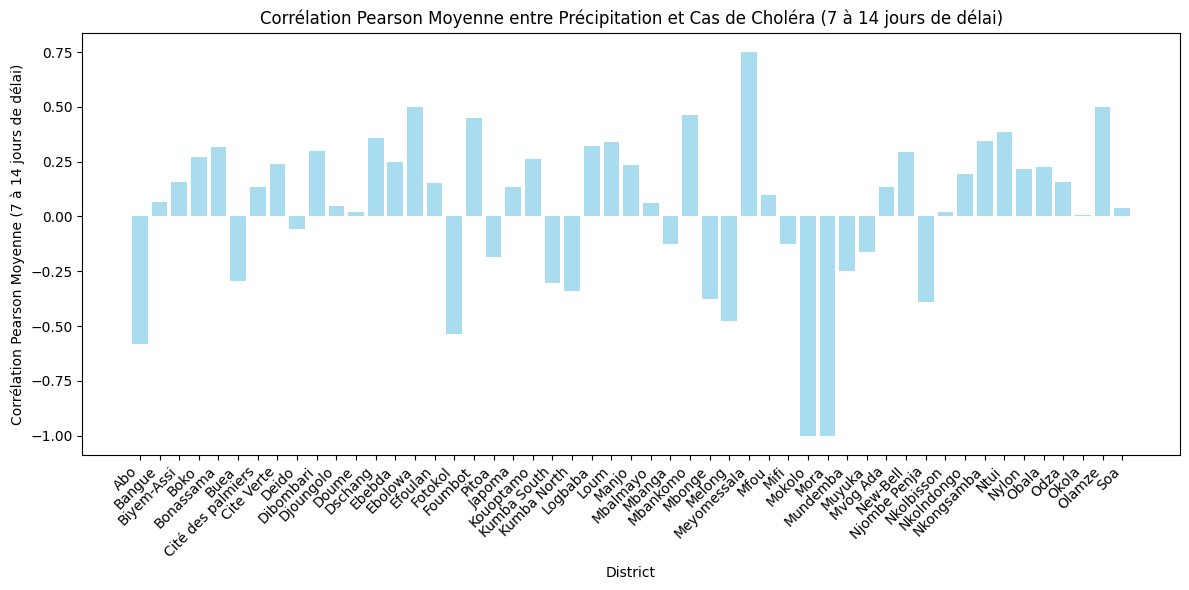

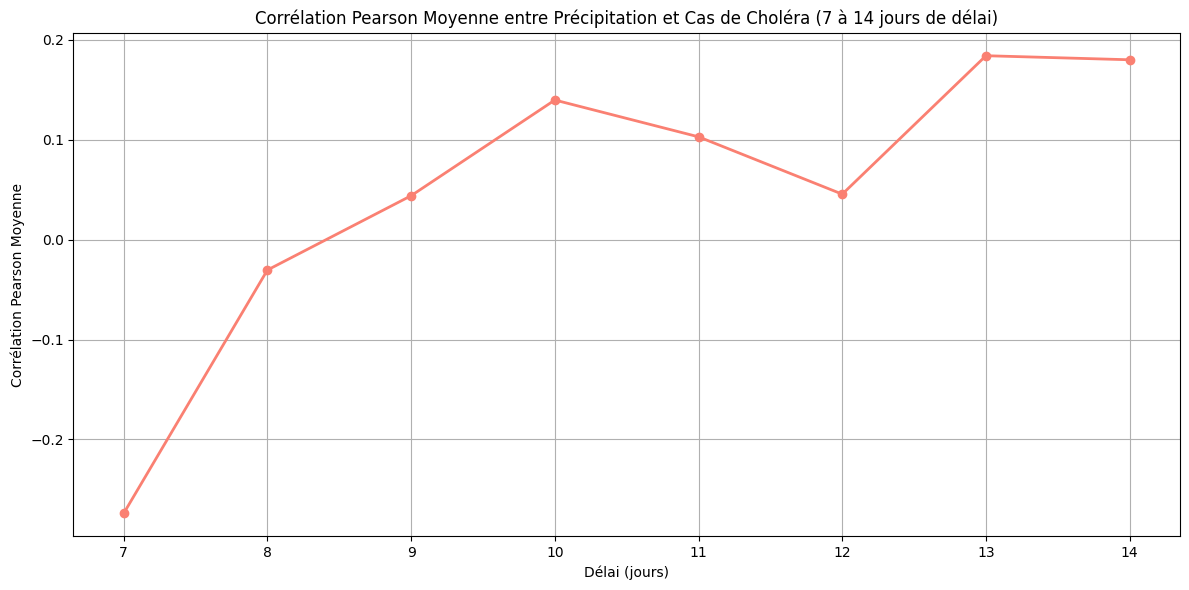

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Ensure datetime format
df['date'] = pd.to_datetime(df['date'])
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Initialize lists to store results per district and lag times
district_results = []
lag_time_results = {lag: [] for lag in range(7, 15)}  # Store correlations for each lag (7 to 14)

# Get unique districts
districts = df['DISTRICT_S'].unique()

# Process each district
for district in districts:
    # Filter data for the current district
    district_precip = df[df['DISTRICT_S'] == district]
    district_cases = incidence_df[incidence_df['DISTRICT_S'] == district]

    # Ensure precipitation data is sorted by date
    district_precip = district_precip.set_index('date').sort_index()

    # List to store correlations for lag times from 7 to 14 days
    correlations = []

    # Loop through lag times from 7 to 14 days
    for lag in range(7, 15):  # lag time from 7 to 14 days
        precip_7_to_14_days_before_cases = []
        valid_cases = []  # To track the cases that have valid precipitation data for this lag

        # Loop through each start_date in the cholera case data
        for start_date in district_cases['start_date']:
            # Get the precipitation for 'lag' days before the case's start_date
            lagged_date = start_date - pd.Timedelta(days=lag)

            # Check if we have precipitation data for the exact lagged date
            if lagged_date in district_precip.index:
                precip_7_to_14_days_before_cases.append(district_precip.loc[lagged_date, 'total_precipitation'])
                valid_cases.append(start_date)

        # If there are any valid cases (i.e., cases with valid precipitation data)
        if len(valid_cases) > 0:
            # Filter district cases for only those with valid precipitation data
            valid_cases_data = district_cases[district_cases['start_date'].isin(valid_cases)].copy()
            valid_cases_data[f'precip_{lag}d_prior'] = precip_7_to_14_days_before_cases

            # Drop NaN values to make sure there's valid data for correlation
            combined = valid_cases_data[['cases', f'precip_{lag}d_prior']].dropna()

            # Compute Pearson correlation if there's enough data
            if len(combined) > 1:  # Ensure there is enough data to compute correlation
                corr, _ = pearsonr(combined['cases'], combined[f'precip_{lag}d_prior'])
                correlations.append(corr)

                # Store the correlation for this lag time
                lag_time_results[lag].append(corr)

    # Calculate the average correlation for this district across all lag times (7 to 14 days)
    if correlations:  # Avoid division by zero if no correlations were computed
        average_corr = sum(correlations) / len(correlations)
        district_results.append({'district': district, 'average_correlation': average_corr})

# Convert the results to DataFrames for easy viewing
district_results_df = pd.DataFrame(district_results)

# Calculate the average correlation for each lag time across all districts
lag_avg_correlation = {lag: sum(corrs) / len(corrs) if corrs else 0 for lag, corrs in lag_time_results.items()}

# Convert to a DataFrame for easy plotting
lag_avg_correlation_df = pd.DataFrame(list(lag_avg_correlation.items()), columns=['Lag Time', 'Average Correlation'])

# Print the results
print("Average Correlation Results per District:")
print(district_results_df)

print("\nAverage Correlation per Lag Time (7 to 14 Days):")
print(lag_avg_correlation_df)

# Plot the average correlations for each district
plt.figure(figsize=(12, 6))

# Plot average correlation for each district
plt.bar(district_results_df['district'], district_results_df['average_correlation'], color='skyblue', alpha=0.7)
plt.xlabel('District')
plt.ylabel('Corrélation Pearson Moyenne (7 à 14 jours de délai)')
plt.title('Corrélation Pearson Moyenne entre Précipitation et Cas de Choléra (7 à 14 jours de délai)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the average correlation per lag time (7 to 14 days)
plt.figure(figsize=(12, 6))

# Plot average correlation for each lag time
plt.plot(lag_avg_correlation_df['Lag Time'], lag_avg_correlation_df['Average Correlation'], marker='o', color='salmon', linestyle='-', linewidth=2)
plt.xlabel('Délai (jours)')
plt.ylabel('Corrélation Pearson Moyenne')
plt.title('Corrélation Pearson Moyenne entre Précipitation et Cas de Choléra (7 à 14 jours de délai)')
plt.grid(True)
plt.tight_layout()
plt.show()

             district  correlation
0                 Abo    -0.272504
1              Bangue     0.457700
2          Biyem-Assi     0.070578
3                Boko     0.742473
4           Bonassama     0.863289
5                Buea    -0.340770
6   Cité des palmiers     0.353297
7          Cite Verte     0.180247
8               Deido     0.094249
9           Dibombari     0.816399
10          Djoungolo     0.334223
11              Doume     0.147249
12            Dschang    -0.651007
13             Ebebda     1.000000
14            Ebolowa     1.000000
15            Efoulan     0.240709
16            Fotokol    -1.000000
17            Foumbot     0.742565
18              Pitoa    -0.333000
19             Japoma     0.697153
20          Kouoptamo     0.834877
21        Kumba South     0.025831
22        Kumba North    -0.375668
23            Logbaba     0.750150
24               Loum     0.449092
25              Manjo     0.605846
26           Mbalmayo     0.296853
27             Mbang

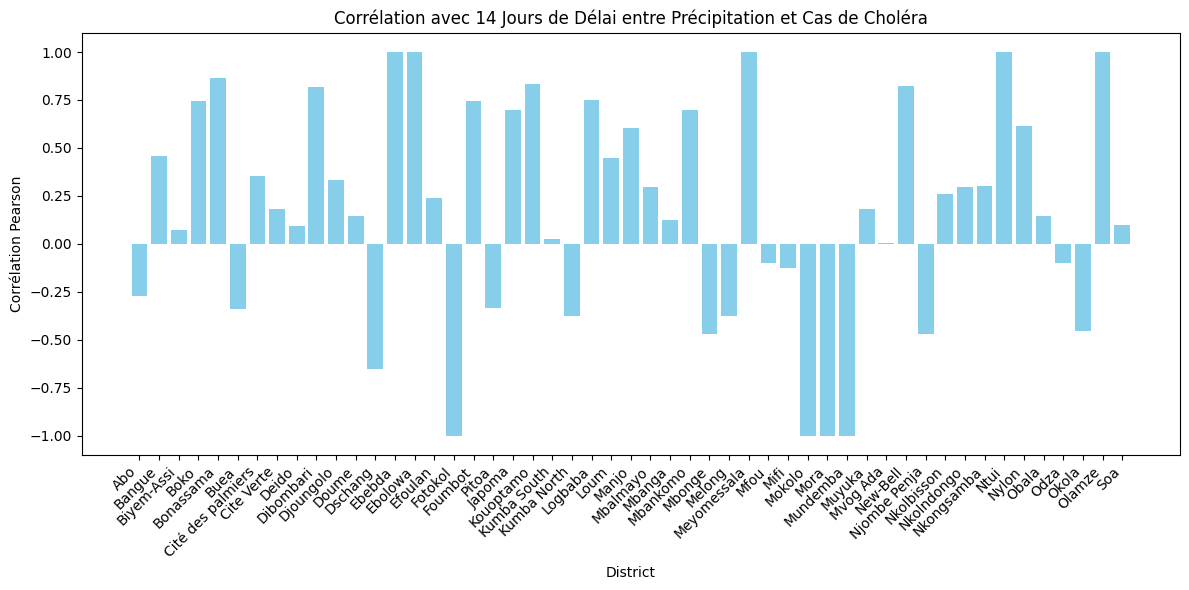

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Ensure datetime format
df['date'] = pd.to_datetime(df['date'])
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Initialize list to store correlation results per district
district_results = []

# Get unique districts
districts = df['DISTRICT_S'].unique()

# Process each district
for district in districts:
    # Filter data for the current district
    district_precip = df[df['DISTRICT_S'] == district]
    district_cases = incidence_df[incidence_df['DISTRICT_S'] == district]

    # Ensure precipitation data is sorted by date
    district_precip = district_precip.set_index('date').sort_index()

    # List to store precipitation data 7 days before each case's start_date
    precip_14_days_before_cases = []
    valid_cases = []  # To track the cases that have valid precipitation data

    # Loop through each start_date in the cholera case data
    for start_date in district_cases['start_date']:
        # Get the precipitation for 14 days before the case's start_date
        fourteen_days_before = start_date - pd.Timedelta(days=14)

        # Check if we have precipitation data for the exact 14 days prior
        if fourteen_days_before in district_precip.index:
            precip_14_days_before_cases.append(district_precip.loc[fourteen_days_before, 'total_precipitation'])
            valid_cases.append(start_date)

    # If there are any valid cases (i.e., cases with valid precipitation data)
    if len(valid_cases) > 0:
        # Filter district cases for only those with valid precipitation data
        valid_cases_data = district_cases[district_cases['start_date'].isin(valid_cases)].copy()
        valid_cases_data['precip_14d_prior'] = precip_14_days_before_cases

        # Drop NaN values to make sure there's valid data for correlation
        combined = valid_cases_data[['cases', 'precip_14d_prior']].dropna()

        # Compute Pearson correlation if there's enough data
        if len(combined) > 1:  # Ensure there is enough data to compute correlation
            corr, _ = pearsonr(combined['cases'], combined['precip_14d_prior'])
            district_results.append({'district': district, 'correlation': corr})

# Convert the results to a DataFrame for easy viewing
district_results_df = pd.DataFrame(district_results)

# Print the correlation results per district
print(district_results_df)

# Plot the results
plt.figure(figsize=(12, 6))

# Plot correlation for each district
plt.bar(district_results_df['district'], district_results_df['correlation'], color='skyblue')
plt.xlabel('District')
plt.ylabel('Corrélation Pearson')
plt.title('Corrélation avec 14 Jours de Délai entre Précipitation et Cas de Choléra')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

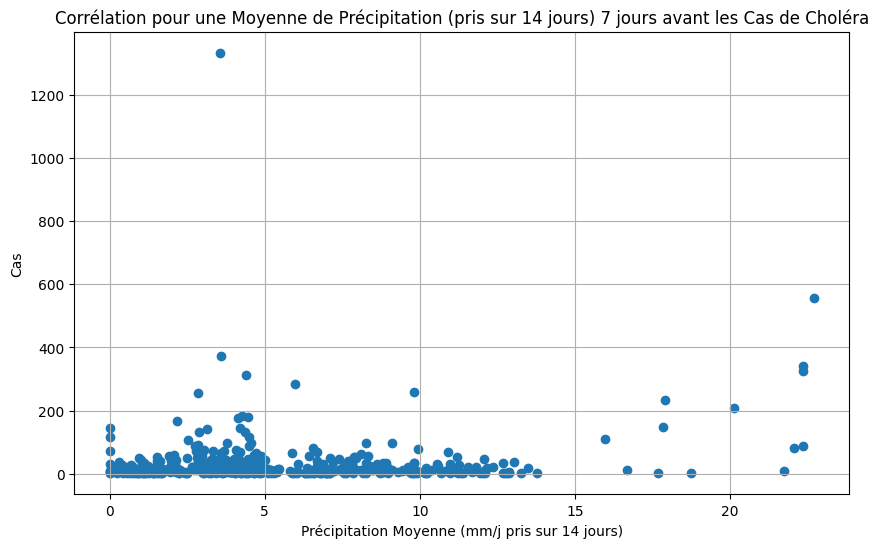

Pearson correlation coefficient: 0.13448287507220702
P-value: 0.004264939879717786


In [60]:
# prompt: take the dates when cases exceed 200 in one district = case_dates, then take 7 days prior to the case_dates = precip_dates, and then take 14 days before precio_dates = accum_dates. Now take the average precipitation for the 14 days of accum_Dates and correlate them on a x-y scatter plot with cases on y and precip on x
# .

# Assuming your DataFrames are named 'df' and 'incidence_df' and already loaded as in your provided code.

# Ensure datetime format
df['date'] = pd.to_datetime(df['date'])
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Initialize lists to store results
case_dates = []
precip_dates = []
accum_dates = []
average_precipitations = []
cases = []

# Define the threshold for cases
case_threshold = 1

# Iterate through each district
for district in incidence_df['DISTRICT_S'].unique():
    # Filter data for the current district
    district_cases = incidence_df[incidence_df['DISTRICT_S'] == district]
    district_precip = df[df['DISTRICT_S'] == district]

    # Set date as index for precipitation data
    district_precip = district_precip.set_index('date').sort_index()

    # Find dates when cases exceed the threshold
    district_case_dates = district_cases[district_cases['cases'] > case_threshold]['start_date'].tolist()

    # Iterate through case dates and calculate precipitation
    for case_date in district_case_dates:
      #7 days prior to case date
      precip_date = case_date - pd.Timedelta(days=7)
      #14 days before precip_date
      accum_start_date = precip_date - pd.Timedelta(days=14)

      #check for valid dates
      if accum_start_date in district_precip.index and precip_date in district_precip.index and case_date in district_cases['start_date'].values:
          # Calculate average precipitation for the 14-day accumulation period
          accum_precip = district_precip.loc[accum_start_date: precip_date, 'total_precipitation']
          avg_precip = (accum_precip.mean())*1000

          case_dates.append(case_date)
          precip_dates.append(precip_date)
          accum_dates.append(accum_start_date)
          average_precipitations.append(avg_precip)
          cases.append(district_cases[district_cases['start_date'] == case_date]['cases'].iloc[0])

# Create a DataFrame for the results
results_df = pd.DataFrame({
    'Case Date': case_dates,
    'Precipitation Date': precip_dates,
    'Accumulation Start Date': accum_dates,
    'Average Precipitation (14 days)': average_precipitations,
    'Cases': cases
})


# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Average Precipitation (14 days)'], results_df['Cases'])
plt.xlabel('Précipitation Moyenne (mm/j pris sur 14 jours)')
plt.ylabel('Cas')
plt.title('Corrélation pour une Moyenne de Précipitation (pris sur 14 jours) 7 jours avant les Cas de Choléra')
plt.grid(True)
plt.show()

# Calculate the Pearson correlation coefficient
correlation, p_value = pearsonr(results_df['Average Precipitation (14 days)'], results_df['Cases'])
print(f"Pearson correlation coefficient: {correlation}")
print(f"P-value: {p_value}")

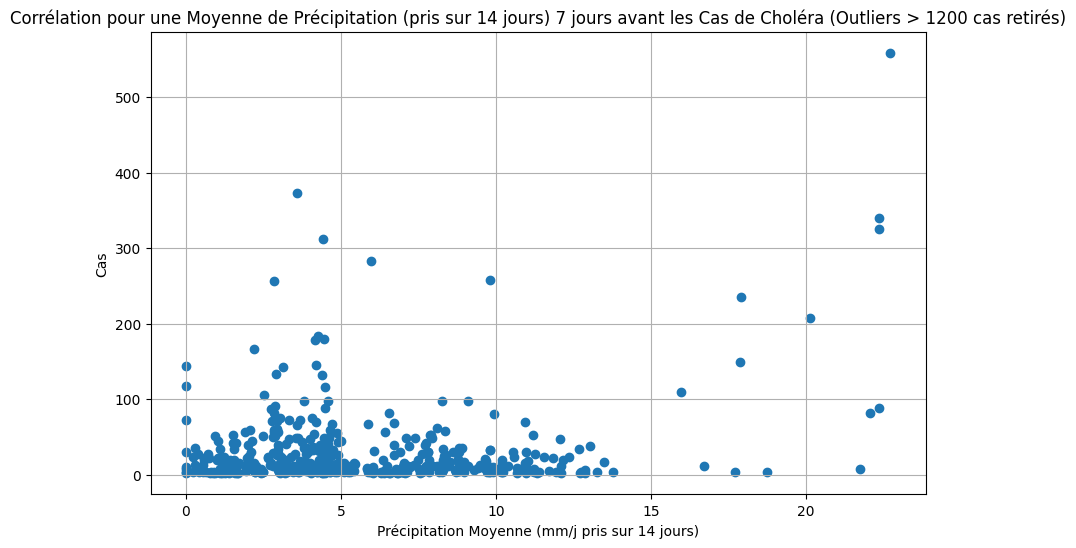

Pearson correlation coefficient: 0.23021563297951952
P-value: 8.182225018148246e-07


In [61]:
# prompt: repeat the correlation analysis above but remove the outlier with over 1200 cases in one day

# Assuming your DataFrames are named 'df' and 'incidence_df' and already loaded as in your provided code.

# Ensure datetime format
df['date'] = pd.to_datetime(df['date'])
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Remove outlier days with over 1200 cases
incidence_df_filtered = incidence_df[incidence_df['cases'] <= 1200]

# Initialize lists to store results
case_dates = []
precip_dates = []
accum_dates = []
average_precipitations = []
cases = []

# Define the threshold for cases
case_threshold = 1

# Iterate through each district
for district in incidence_df_filtered['DISTRICT_S'].unique():
    # Filter data for the current district
    district_cases = incidence_df_filtered[incidence_df_filtered['DISTRICT_S'] == district]
    district_precip = df[df['DISTRICT_S'] == district]

    # Set date as index for precipitation data
    district_precip = district_precip.set_index('date').sort_index()

    # Find dates when cases exceed the threshold
    district_case_dates = district_cases[district_cases['cases'] > case_threshold]['start_date'].tolist()

    # Iterate through case dates and calculate precipitation
    for case_date in district_case_dates:
      #7 days prior to case date
      precip_date = case_date - pd.Timedelta(days=7)
      #14 days before precip_date
      accum_start_date = precip_date - pd.Timedelta(days=14)

      #check for valid dates
      if accum_start_date in district_precip.index and precip_date in district_precip.index and case_date in district_cases['start_date'].values:
          # Calculate average precipitation for the 14-day accumulation period
          accum_precip = district_precip.loc[accum_start_date: precip_date, 'total_precipitation']
          avg_precip = (accum_precip.mean())*1000

          case_dates.append(case_date)
          precip_dates.append(precip_date)
          accum_dates.append(accum_start_date)
          average_precipitations.append(avg_precip)
          cases.append(district_cases[district_cases['start_date'] == case_date]['cases'].iloc[0])

# Create a DataFrame for the results
results_df = pd.DataFrame({
    'Case Date': case_dates,
    'Precipitation Date': precip_dates,
    'Accumulation Start Date': accum_dates,
    'Average Precipitation (14 days)': average_precipitations,
    'Cases': cases
})


# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Average Precipitation (14 days)'], results_df['Cases'])
plt.xlabel('Précipitation Moyenne (mm/j pris sur 14 jours)')
plt.ylabel('Cas')
plt.title('Corrélation pour une Moyenne de Précipitation (pris sur 14 jours) 7 jours avant les Cas de Choléra (Outliers > 1200 cas retirés)')
plt.grid(True)
plt.show()

# Calculate the Pearson correlation coefficient
correlation, p_value = pearsonr(results_df['Average Precipitation (14 days)'], results_df['Cases'])
print(f"Pearson correlation coefficient: {correlation}")
print(f"P-value: {p_value}")

No cases exceeding 150 for district Biyem-Assi


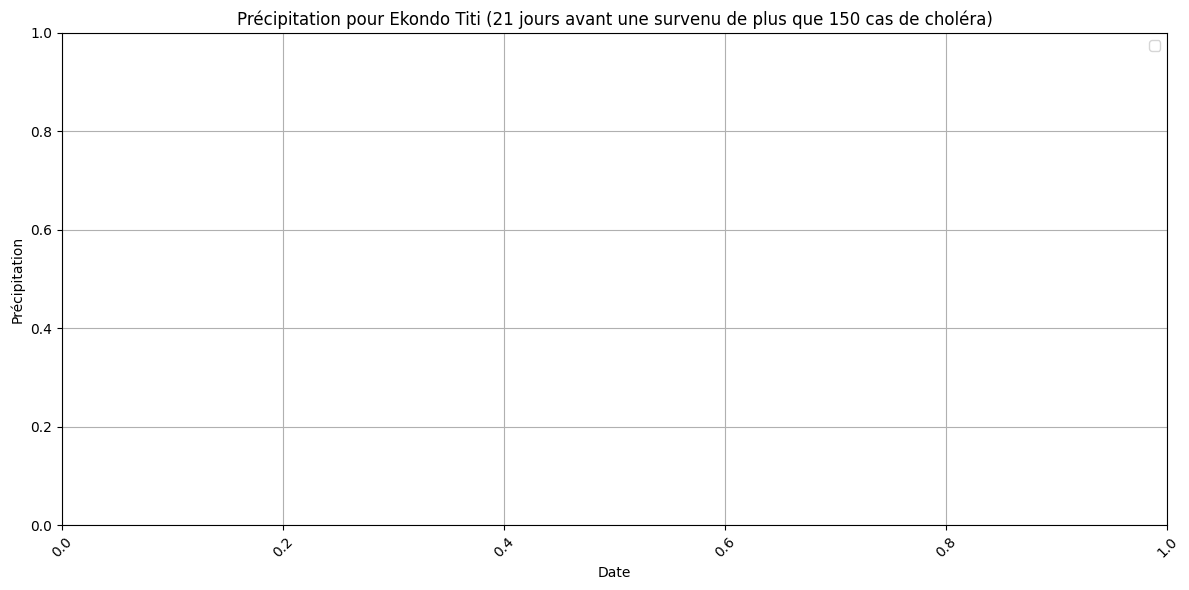

No cases exceeding 150 for district Efoulan
No cases exceeding 150 for district Mfou


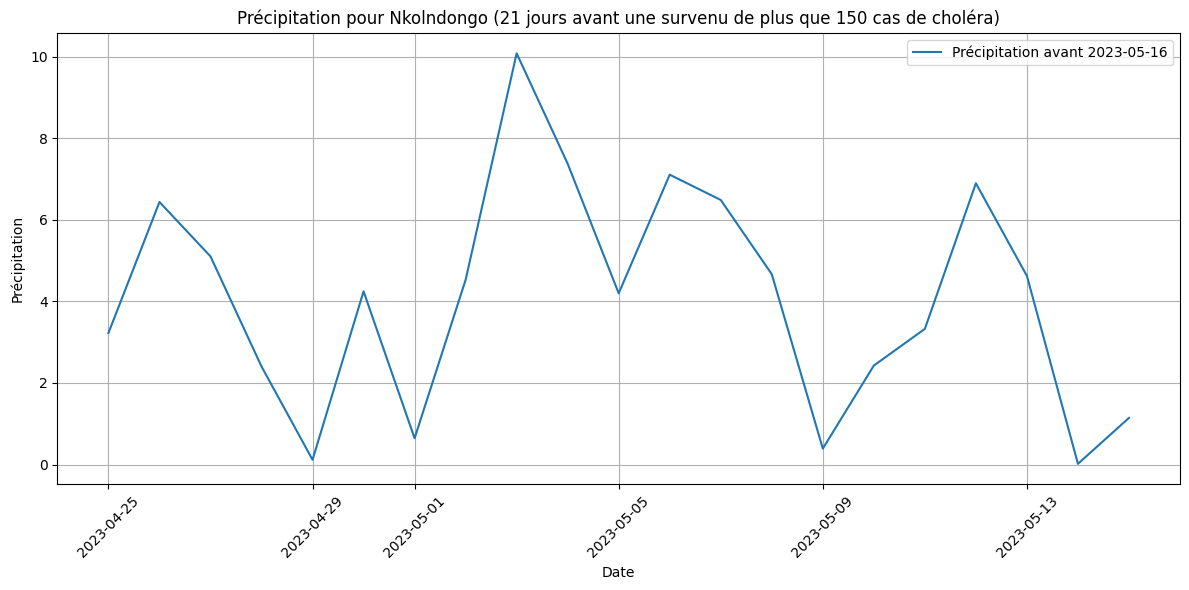

No cases exceeding 150 for district Soa
No cases exceeding 150 for district Mbonge
No cases exceeding 150 for district Bakassi


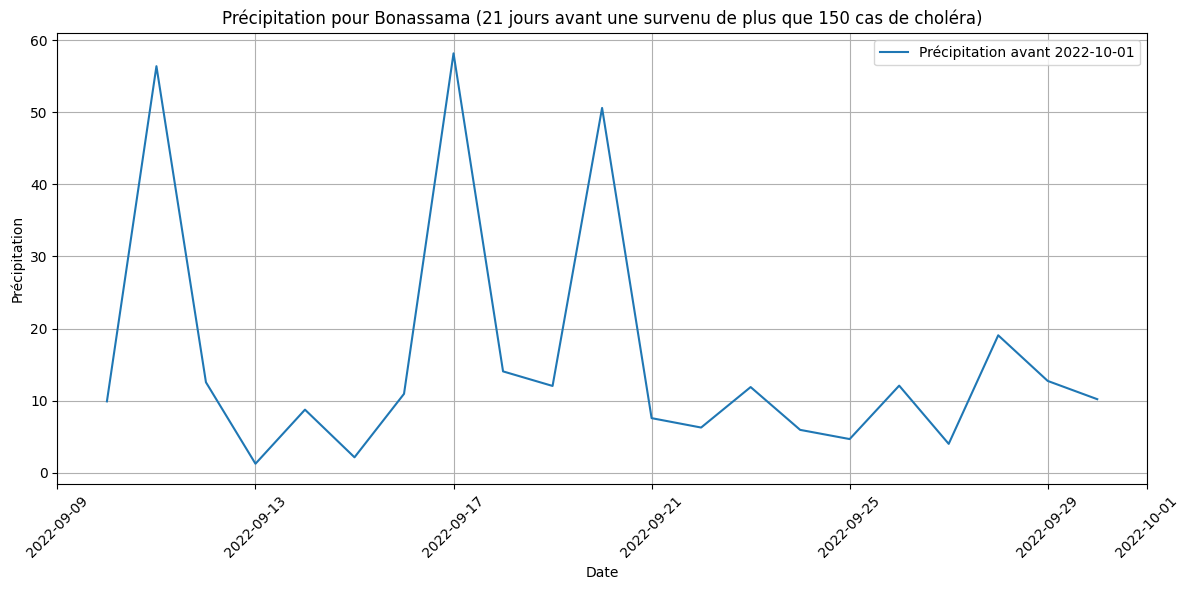

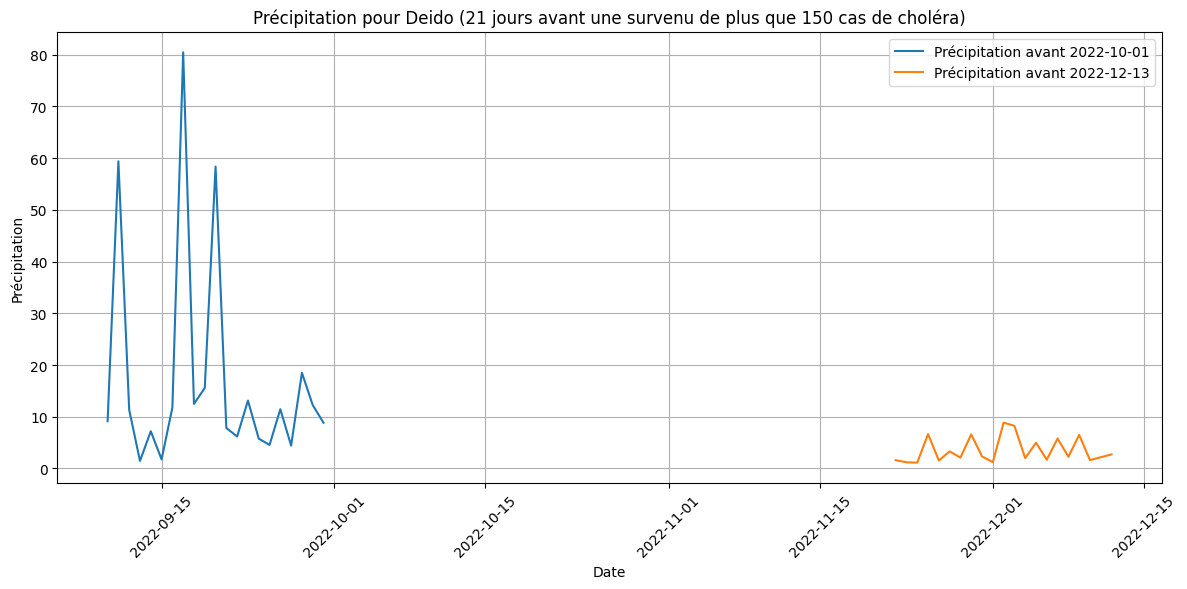

No cases exceeding 150 for district Manoka
No cases exceeding 150 for district Bangue
No cases exceeding 150 for district Japoma


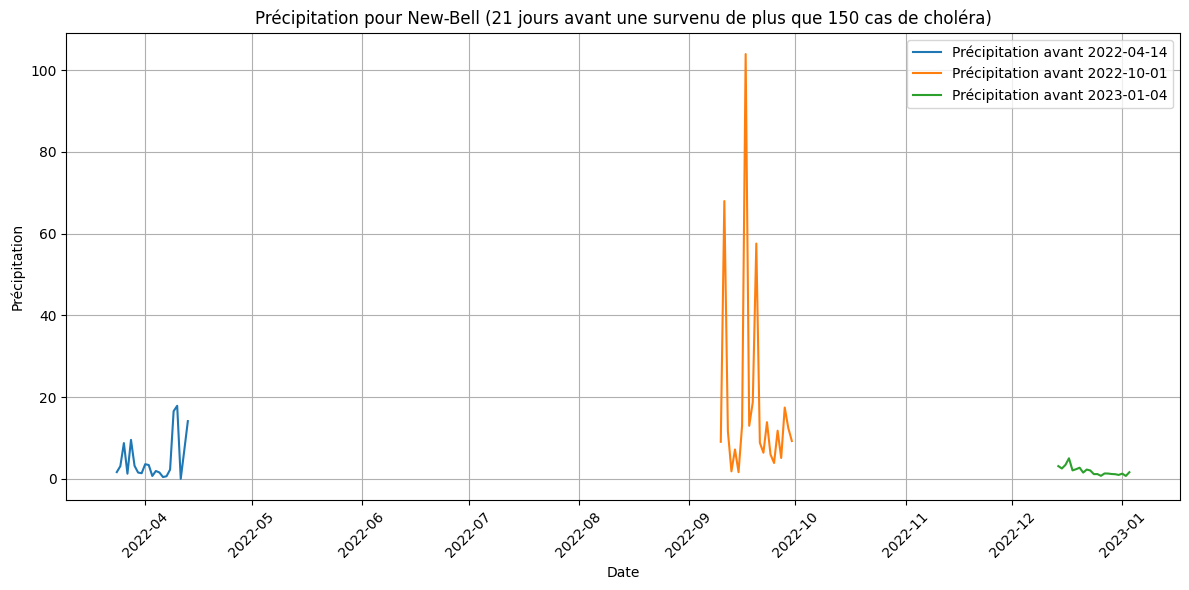

No cases exceeding 150 for district Kribi


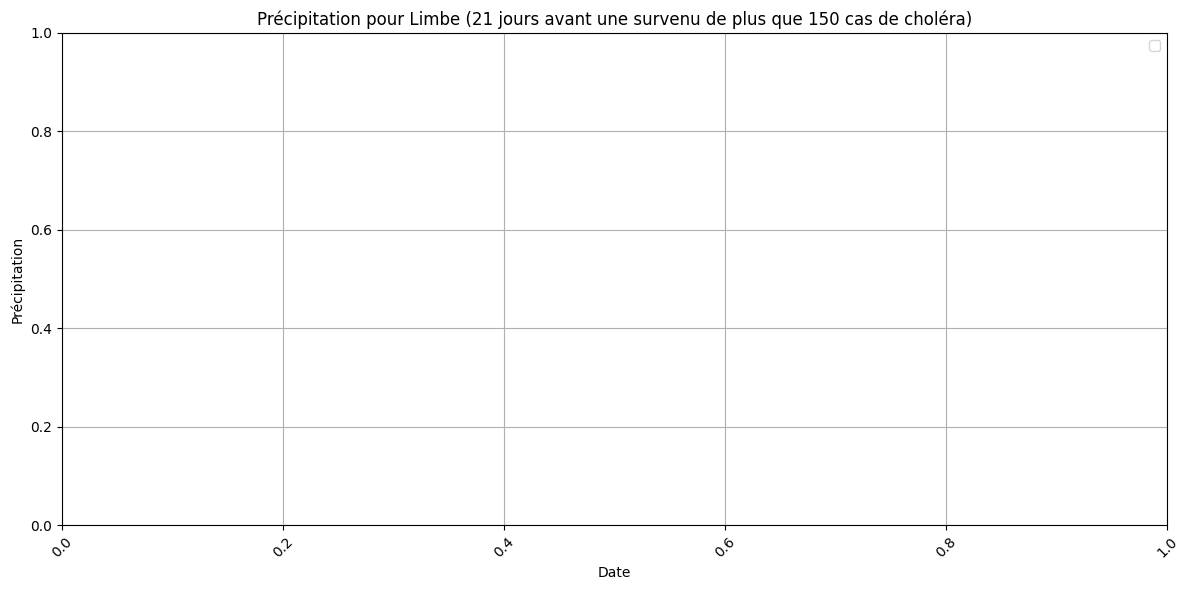

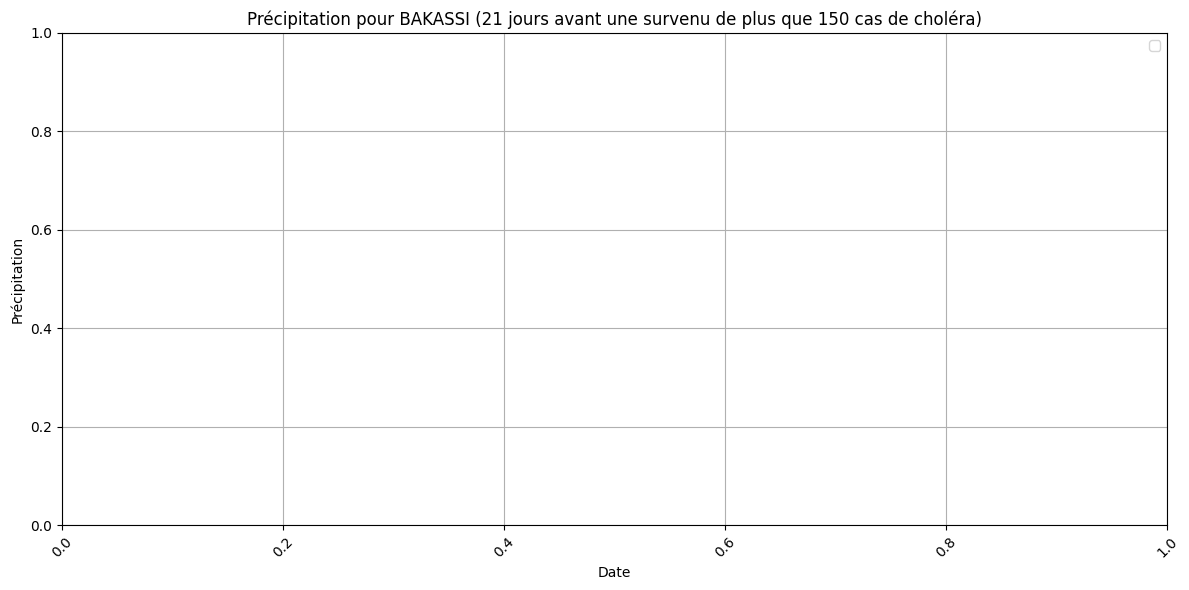

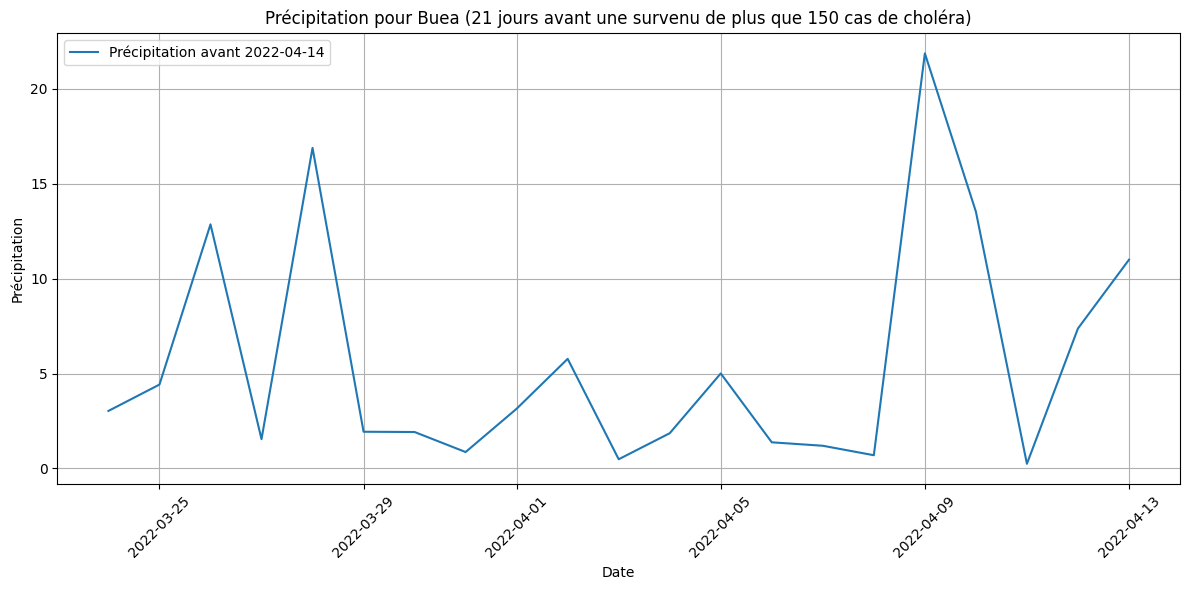

No cases exceeding 150 for district MBONGE
No cases exceeding 150 for district KRIBI
No cases exceeding 150 for district Logbaba
No cases exceeding 150 for district DEIDO


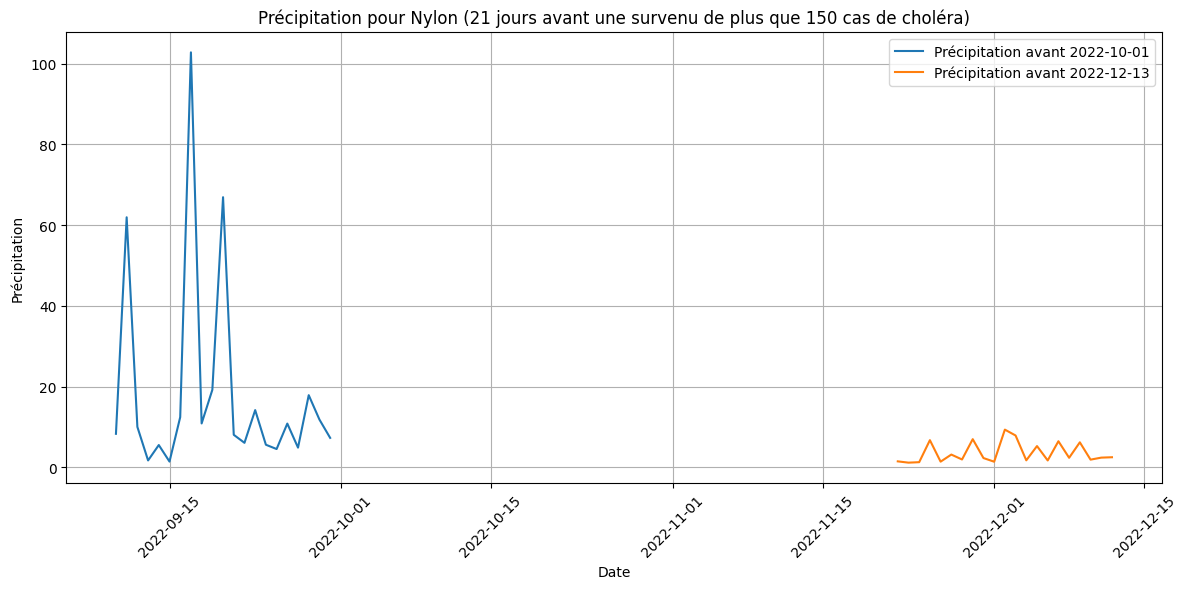

No cases exceeding 150 for district Fotokol


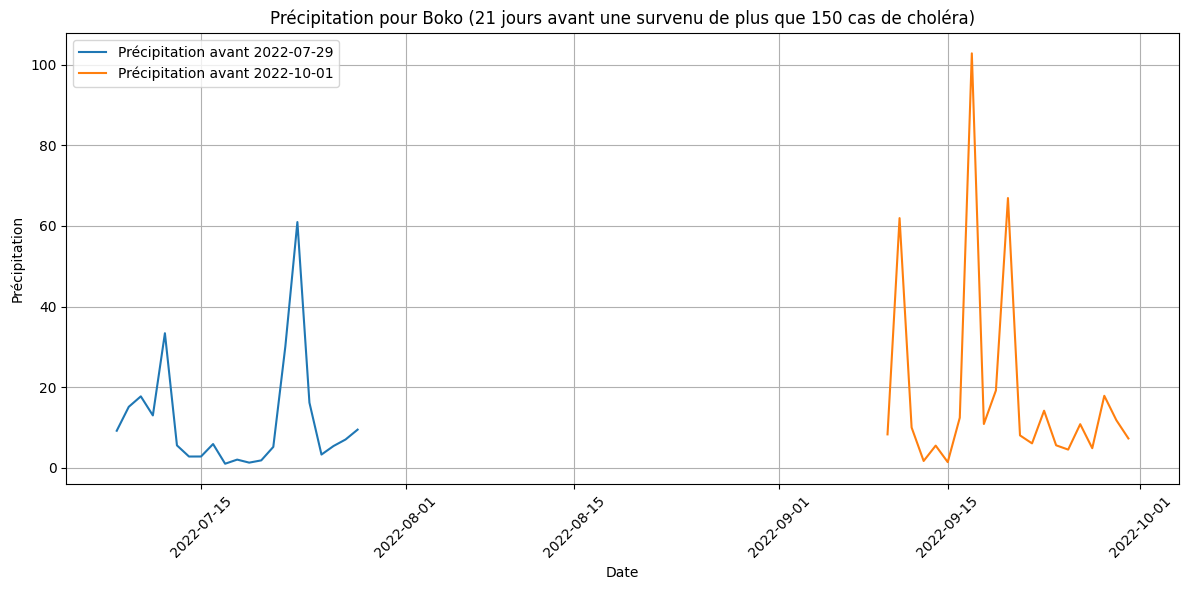

No cases exceeding 150 for district Melong
No cases exceeding 150 for district Pitoa
No cases exceeding 150 for district Kumba North
No cases exceeding 150 for district Kumba South


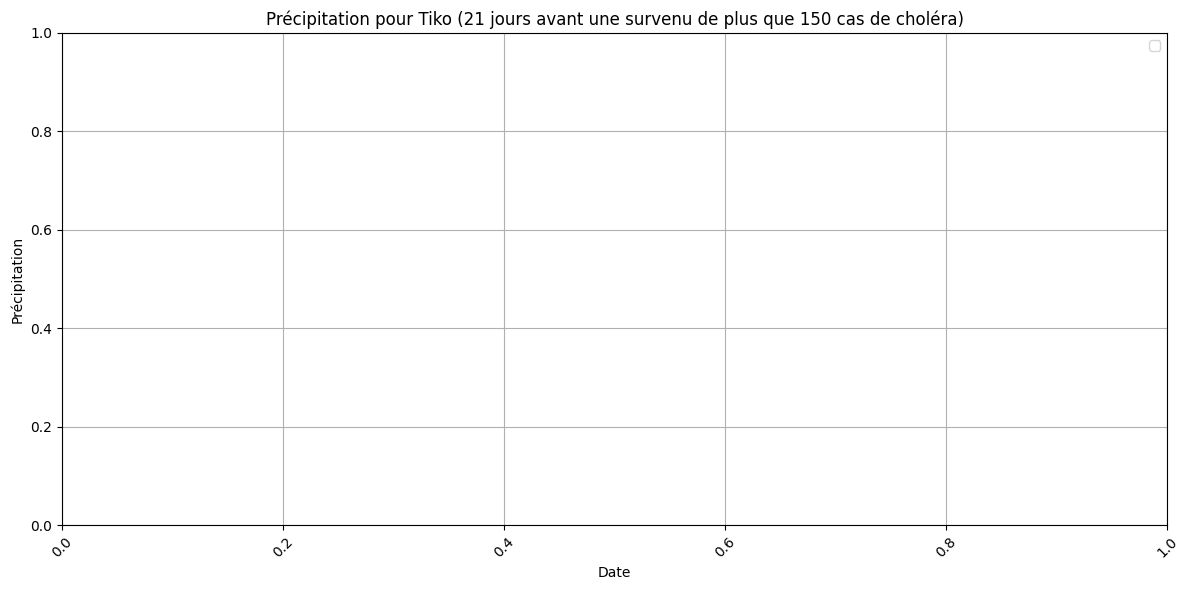

No cases exceeding 150 for district BANGUE


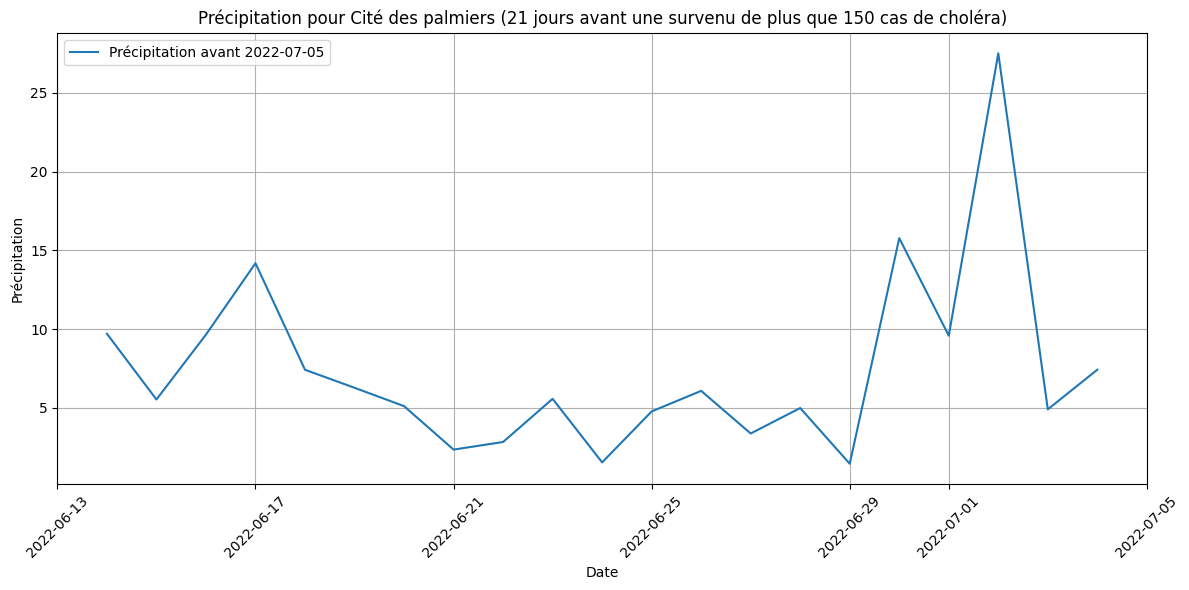

No cases exceeding 150 for district Njombe Penja
No cases exceeding 150 for district Muyuka
No cases exceeding 150 for district MELONG


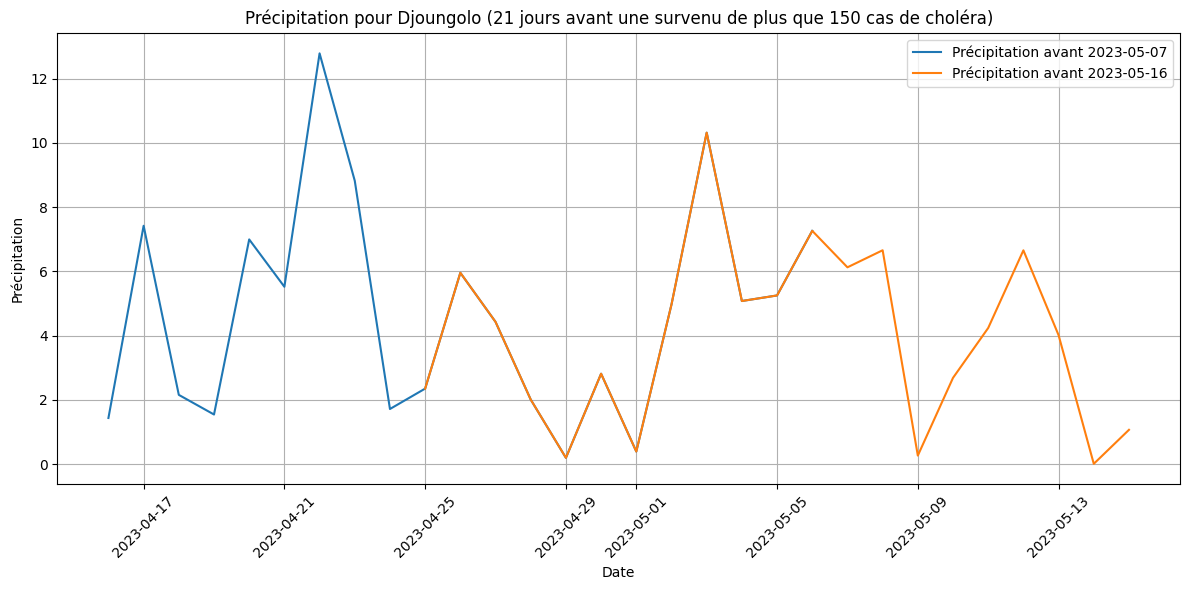

No cases exceeding 150 for district Mundemba
No cases exceeding 150 for district Dibombari
No cases exceeding 150 for district Mbanga
No cases exceeding 150 for district Cite Verte
No cases exceeding 150 for district Odza
No cases exceeding 150 for district Mifi
No cases exceeding 150 for district Mamfe
No cases exceeding 150 for district Abo
No cases exceeding 150 for district Edea
No cases exceeding 150 for district Loum
No cases exceeding 150 for district Manjo
No cases exceeding 150 for district Nkongsamba
No cases exceeding 150 for district Mvog Ada
No cases exceeding 150 for district Dschang
No cases exceeding 150 for district Foumbot
No cases exceeding 150 for district Kouoptamo
No cases exceeding 150 for district Doume
No cases exceeding 150 for district Mora
No cases exceeding 150 for district Mokolo
No cases exceeding 150 for district Obala
No cases exceeding 150 for district Ntui
No cases exceeding 150 for district Mbankomo
No cases exceeding 150 for district Bafia
No cases 

In [62]:
# prompt: plot a timleine graph per district of precipitation for the 21 days before every moment cases exceed 150

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrames are named 'df' and 'incidence_df' and already loaded
# ... (your existing code to load the data)

# Ensure datetime format
df['date'] = pd.to_datetime(df['date'])
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Function to plot the timeline for a specific district
def plot_district_timeline(district, days_before=21):
    district_cases = incidence_df[(incidence_df['DISTRICT_S'] == district) & (incidence_df['cases'] > 150)]

    if district_cases.empty:
        print(f"No cases exceeding 150 for district {district}")
        return

    fig, ax = plt.subplots(figsize=(12, 6))

    for case_date in district_cases['start_date']:
        start_date = case_date - pd.Timedelta(days=days_before)
        end_date = case_date

        district_precipitation = df[(df['DISTRICT_S'] == district) & (df['date'] >= start_date) & (df['date'] < end_date)]

        if not district_precipitation.empty:
            ax.plot(district_precipitation['date'], district_precipitation['total_precipitation']*1000, label=f"Précipitation avant {case_date.strftime('%Y-%m-%d')}")

    ax.set_xlabel('Date')
    ax.set_ylabel('Précipitation')
    ax.set_title(f'Précipitation pour {district} (21 jours avant une survenu de plus que 150 cas de choléra)')
    ax.grid(True)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Iterate through unique districts and plot their timelines
for district in incidence_df['DISTRICT_S'].unique():
    plot_district_timeline(district)

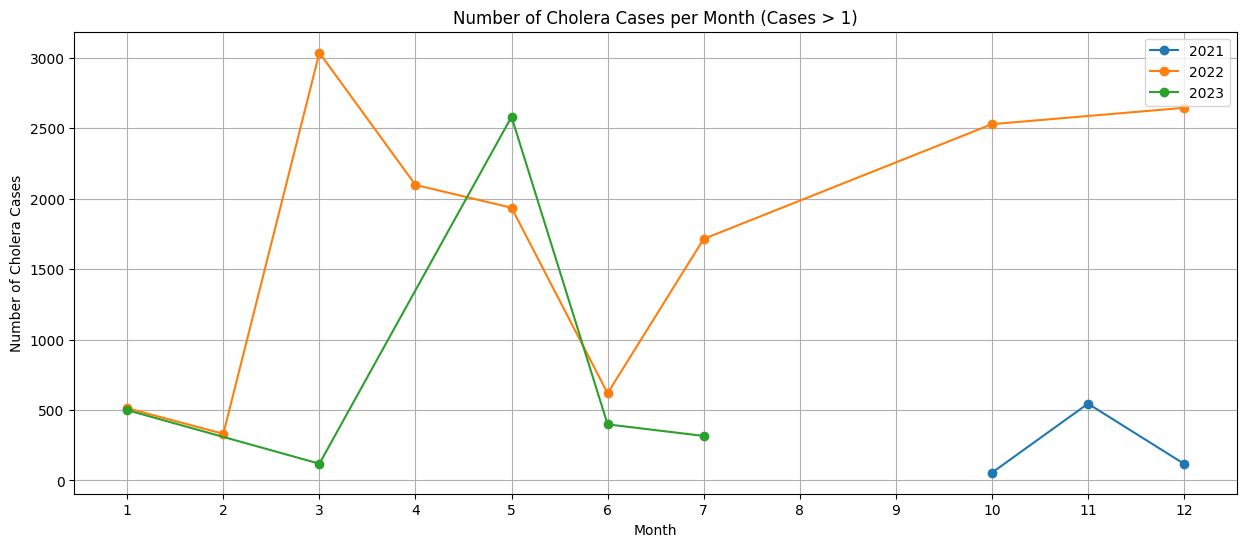

In [63]:
# prompt: plot the number of months in a year there is more than 1 cholera case confirmed, while highlighting the months with no cases, and dont aggregate by year, show for all years of the data

import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'incidence_df' and 'start_date' and 'cases' columns exist
# Replace 'incidence_df' with your actual DataFrame name if different

# Convert 'start_date' to datetime objects if it's not already
incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

# Extract year and month
incidence_df['year'] = incidence_df['start_date'].dt.year
incidence_df['month'] = incidence_df['start_date'].dt.month

# Group by year and month, then count cases exceeding the threshold (e.g., 1)
monthly_cases = incidence_df.groupby(['year', 'month'])['cases'].sum().reset_index()

# Create the plot
plt.figure(figsize=(15, 6))  # Adjust figure size as needed

# Plot each year separately
for year in monthly_cases['year'].unique():
  year_data = monthly_cases[monthly_cases['year'] == year]
  plt.plot(year_data['month'], year_data['cases'], label=str(year), marker='o')

# Highlight months with no cases
# You'll need to identify the years with no cases separately. Here's how:
for year in monthly_cases['year'].unique():
    year_data = monthly_cases[monthly_cases['year'] == year]
    months_with_no_cases = [month for month in range(1, 13) if month not in year_data['month'].values]


plt.xlabel('Month')
plt.ylabel('Number of Cholera Cases')
plt.title('Number of Cholera Cases per Month (Cases > 1)')
plt.xticks(range(1, 13))  # Ensure all months are displayed on the x-axis
plt.legend()
plt.grid(True)
plt.show()

In [69]:
# prompt: if the precipitation daily average in a district is over 50mm for 4 days, take note of that district and date, then note if that district ever exceeds 5 cholera cases and the date that is. Do this for all districts that pass 50mm average  over 4 day moving average

def analyze_districts(df, incidence_df):
    # Ensure datetime format
    df['date'] = pd.to_datetime(df['date'])
    incidence_df['start_date'] = pd.to_datetime(incidence_df['start_date'])

    districts_over_threshold = {}

    for district in df['DISTRICT_S'].unique():
        district_data = df[df['DISTRICT_S'] == district].copy()
        district_data['4_day_avg_precipitation'] = district_data['total_precipitation'].rolling(window=5).mean()

        # Identify dates when 4-day average precipitation exceeds 50mm
        high_precipitation_dates = district_data[district_data['4_day_avg_precipitation'] > 0.05]['date'].tolist()
        if high_precipitation_dates:
          districts_over_threshold[district] = high_precipitation_dates

    EAP_triggers = {}

    for district, dates in districts_over_threshold.items():
        district_cases = incidence_df[incidence_df['DISTRICT_S'] == district]
        exceeds_5_cases = district_cases[district_cases['cases'] > 5]
        after_precipitation = exceeds_5_cases[exceeds_5_cases['start_date'] > min(dates)]
        if not after_precipitation.empty:
            EAP_triggers[district] = after_precipitation

    return districts_over_threshold, EAP_triggers


# Example usage (replace 'df' and 'incidence_df' with your actual DataFrames):
districts_over_threshold, EAP_triggers = analyze_districts(df, incidence_df)


#print results
print("Districts with > 50mm average precipitation over 4 days:")
for district, dates in districts_over_threshold.items():
    print(f"District: {district}, Dates: {dates}")

print("\nEAP_triggers (> 5 cases) in affected districts:")
for district, outbreak_data in EAP_triggers.items():
    print(f"District: {district}")
    print(outbreak_data[['start_date', 'cases']])

Districts with > 50mm average precipitation over 4 days:
District: Buea, Dates: [Timestamp('2022-08-15 00:00:00'), Timestamp('2023-07-26 00:00:00')]
District: Fontem, Dates: [Timestamp('2022-06-20 00:00:00')]
District: Kumba North, Dates: [Timestamp('2022-08-12 00:00:00'), Timestamp('2022-08-15 00:00:00'), Timestamp('2022-08-16 00:00:00')]
District: Mbonge, Dates: [Timestamp('2022-08-12 00:00:00'), Timestamp('2022-08-15 00:00:00'), Timestamp('2022-08-16 00:00:00')]
District: Muyuka, Dates: [Timestamp('2022-08-15 00:00:00')]
District: Njikwa, Dates: [Timestamp('2022-09-29 00:00:00')]

EAP_triggers (> 5 cases) in affected districts:


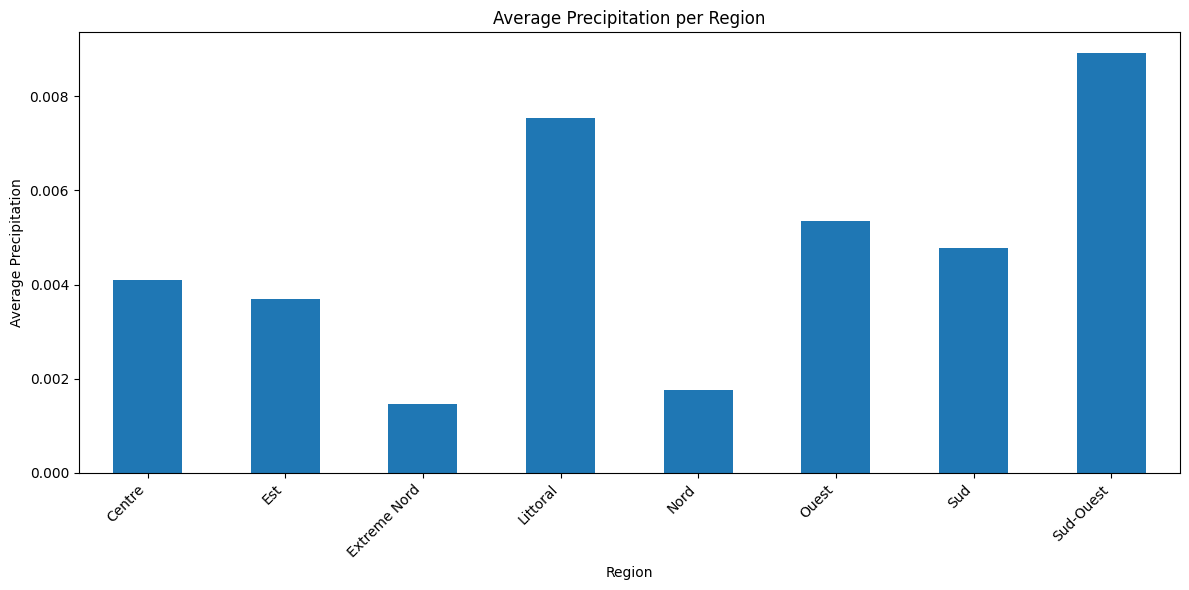

In [65]:
# prompt: make a bar chart of the of the average precipitation for the whole year per NOM_REGION, having merged inicdence_df and df on district to get the regions

# Merge the two dataframes
merged_df = pd.merge(incidence_df, df, on='DISTRICT_S', how='inner')

# Group by region and calculate the average precipitation
average_precipitation_by_region = merged_df.groupby('NOM_REGION')['total_precipitation'].mean()

# Create the bar chart
plt.figure(figsize=(12, 6))
average_precipitation_by_region.plot(kind='bar')
plt.xlabel('Region')
plt.ylabel('Average Precipitation')
plt.title('Average Precipitation per Region')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

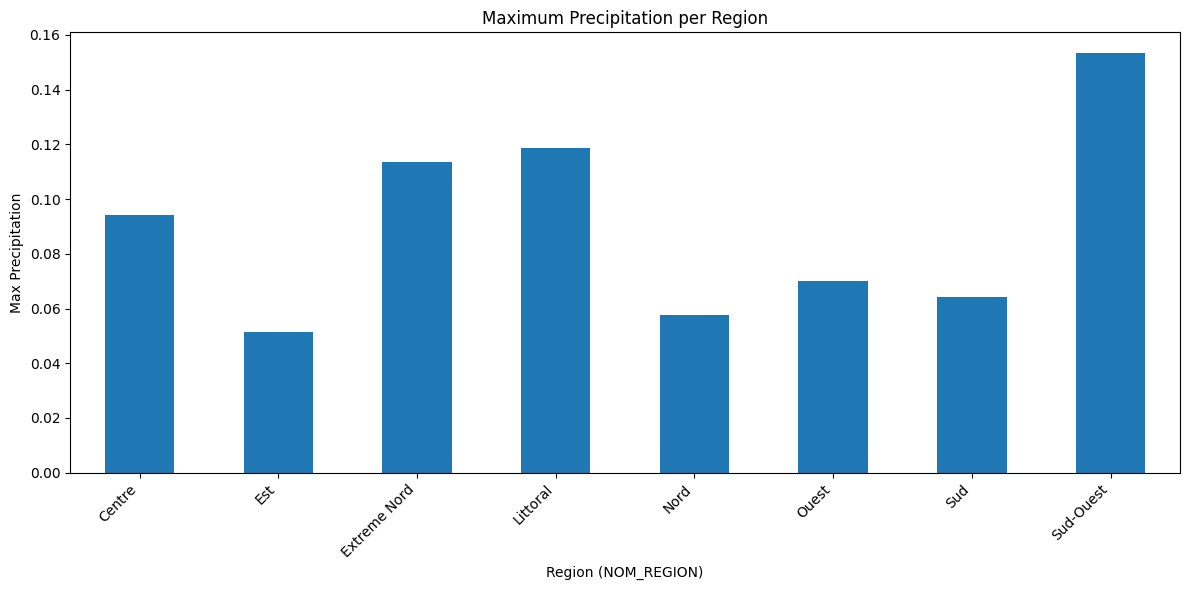

In [66]:
# prompt: make a grouped bar chart of the of the max precipitation for the whole year per district with NOM_REGION being the groups, having merged inicdence_df and df on district to get the regions

import matplotlib.pyplot as plt

# Assuming 'merged_df' is already created as in your provided code.

# Group by 'NOM_REGION' and find the maximum precipitation for each region
max_precipitation_by_region = merged_df.groupby('NOM_REGION')['total_precipitation'].max()

# Create the grouped bar chart
plt.figure(figsize=(12, 6))
max_precipitation_by_region.plot(kind='bar')
plt.xlabel('Region (NOM_REGION)')
plt.ylabel('Max Precipitation')
plt.title('Maximum Precipitation per Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()